
# 08 — Sequence models: CNN, RNN, LSTM, GRU

**Do the deep sequence models actually beat the tree ensembles?** The original study
said yes and its evidence could not support the claim. This notebook settles it.

The original reported a CNN at 9.69 RMSE on GP against XGBoost at 13.91 and concluded
the architectures were better. They were never compared on equal terms:

| | training rows it got |
|---|---|
| CNN / LSTM / GRU / RNN | `train_size=0.7` — roughly **600** |
| XGBoost / Random Forest | the `lag_336` → `dropna()` → date-split path — **88** |

A model with 600 training rows beating one with 88 tells you about the split, not the
architecture. Here every model — sequence and tree alike — reads the **same** univariate
window of 24 consecutive sample lags on the **same** rolling-origin folds, which is the
input shape the original gave its sequence models (`input_shape=(lookback, 1)`).

Architectures and hyperparameters are the original's, unchanged: `Conv1D(64, 3)`,
`LSTM(64)`, `GRU(64)`, `SimpleRNN(50)`, 30 epochs, Adam, MSE. Anything that differs in
the results is therefore the protocol, not retuning.

In [1]:
# --- Bootstrap: works locally, on Colab and on Kaggle ----------------------
# RUN THIS CELL FIRST, and re-run it after any kernel restart. Every later cell
# depends on it. If it fails, the next cell fails with "No module named bwalloc",
# which looks like a different problem but is not.
#
# On a hosted runtime it clones the repo (or pulls, on a re-run) and installs the
# package into the session, so `import bwalloc` keeps working even from a cell you
# run on its own after restarting. The repository is public; no token is needed.
import os, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "https://github.com/sad-code-at/bwalloc.git"

def _find_root(start: Path):
    node = start
    while not (node / "src" / "bwalloc").exists() and node != node.parent:
        node = node.parent
    return node if (node / "src" / "bwalloc").exists() else None

ROOT = _find_root(Path.cwd())

if ROOT is None:
    # A repo uploaded as a Kaggle Dataset mounts read-only here; prefer it if present.
    for candidate in Path("/kaggle/input").glob("*/src/bwalloc"):
        ROOT = candidate.parent.parent
        break

if ROOT is None:
    on_kaggle = Path("/kaggle/working").exists()
    target = Path("/kaggle/working/bwalloc") if on_kaggle else Path("/content/bwalloc")
    if _find_root(target) is None:
        if os.system("git clone -q " + REPO + " " + str(target)) != 0 or _find_root(target) is None:
            raise RuntimeError(
                "Clone failed. On Kaggle, switch Internet ON in the right sidebar "
                "(Settings > Internet), then re-run this cell. See docs/KAGGLE.md."
            )
        print("cloned", REPO)
    else:
        os.system("git -C " + str(target) + " pull -q --ff-only")
        print("pulled latest into", target)
    os.chdir(target)
    ROOT = target
    # Install into the session so `import bwalloc` survives a kernel restart and
    # does not depend on this cell having set sys.path. --no-deps deliberately:
    # Kaggle and Colab curate their own numpy/pandas and we must not disturb them.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
                   cwd=str(ROOT), capture_output=True)

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
_data = sorted((ROOT / "data").glob("*.csv"))
_res = sorted(RESULTS.glob("*.csv"))
print("bwalloc", bw.__version__, "at", ROOT)
print(f"  data/    {len(_data)} csv  ({', '.join(f.name for f in _data) or 'MISSING'})")
print(f"  results/ {len(_res)} csv")
if not _data:
    raise RuntimeError(
        "The trace CSVs are missing, so nothing will run. Re-run this cell to "
        "re-clone, or check that the repository was fetched completely."
    )

bwalloc 0.1.0 at D:\L4-T-1\EEE 402\project\bwalloc
  data/    2 csv  (gp_dhaka.csv, robi_dhaka3.csv)
  results/ 46 csv



## Setup

`sequence_feature_config(24)` builds a design matrix of `lagS_1 … lagS_24` and nothing
else — no Fourier terms, no calendar integers, no context flags. A univariate sequence
model cannot consume those anyway, and giving the trees extra features here would
reintroduce exactly the kind of unequal comparison this notebook exists to remove.

The window is built by the ordinary leak-safe feature builder, so no separate leakage
argument is needed: `assert_no_leakage` covers it.

In [2]:

from bwalloc.baselines import SeasonalNaive, standard_baselines
from bwalloc.data import load, sampling_profile
from bwalloc.evaluate import beats_baseline, dm_matrix, run_backtest, summarise
from bwalloc.features import FeatureConfig, assert_no_leakage, build_features
from bwalloc.models import default_point_models
from bwalloc.sequence import sequence_feature_config, sequence_models
from bwalloc.splits import rolling_origin

OPERATOR = "gp"          # switch to "robi" and re-run
N_FOLDS, LOOKBACK, EPOCHS = 8, 24, 30

df = load(OPERATOR)
profile = sampling_profile(df)
config = sequence_feature_config(LOOKBACK)
assert_no_leakage(df, profile, config)          # gate: refuse to proceed if it leaks

X, y = build_features(df, profile, config)
folds = rolling_origin(len(y), n_folds=N_FOLDS)
print(f"{OPERATOR.upper()}: {X.shape[0]} rows x {X.shape[1]} lag columns, {N_FOLDS} folds")

GP: 881 rows x 24 lag columns, 8 folds



## The comparison

Four sequence models and three tree/linear models on identical folds, against the full
set of naive baselines. On CPU this takes about two minutes.

In [3]:

# What the original study reported, for the side-by-side.
ORIGINAL = {
    "gp": {"cnn": 9.69, "rnn": 10.06, "lstm": 10.67, "gru": 12.14,
           "xgboost": 13.91, "random_forest": 14.96},
    "robi": {"cnn": 20.63, "rnn": 21.6, "lstm": 25.0, "gru": 27.5,
             "xgboost": 22.72, "random_forest": 30.10},
}

baselines = standard_baselines(y.to_numpy(), profile.daily_period)
baselines.append(SeasonalNaive(y.to_numpy(), period=24))

models = sequence_models(lookback=LOOKBACK, epochs=EPOCHS) + default_point_models()
per_fold, predictions = run_backtest(
    X, y, folds, models=models, baselines=baselines,
    season_lag=profile.daily_period,
)

summary = beats_baseline(summarise(per_fold))
view = summary[["model", "rmse_mean", "rmse_std", "mae_mean", "mase_mean",
                "vs_persistence", "beats_persistence"]].copy()
view["originally_reported"] = view["model"].map(ORIGINAL[OPERATOR])
view

,model,rmse_mean,rmse_std,mae_mean,mase_mean,vs_persistence,beats_persistence,originally_reported
0,cnn,7.875288,1.029354,5.607822,0.399187,0.352574,True,9.69
1,gru,8.558696,1.031594,6.289707,0.447722,0.296391,True,12.14
2,rnn,8.625382,0.864787,6.413845,0.456622,0.290909,True,10.06
3,random_forest,8.672923,1.430486,5.856468,0.417142,0.287001,True,14.96
4,lstm,8.816085,0.797245,6.497407,0.462555,0.275231,True,10.67
5,xgboost,8.845865,1.661012,5.953133,0.424143,0.272783,True,13.91
6,ridge,8.879396,1.331639,6.799361,0.483975,0.270027,True,NaN
7,persistence,12.163999,1.089689,6.522293,0.464357,0.000000,False,NaN
8,rolling_mean_17,16.137667,1.637498,12.452828,0.886530,-0.326674,False,NaN
9,train_mean,18.212375,2.049331,14.739177,1.049560,-0.497236,False,NaN



**On GP the CNN wins — 7.88 against random forest's 8.67 — and every model in the table
beats persistence.** Compare the last column: every one of the original's numbers was
worse than what the same architecture achieves here, and the tree models improved most
(14.96 → 8.67) because they were the ones the broken split starved.

On Robi nothing separates: GRU 19.88, ridge 20.14, CNN 20.16, random forest 20.52. The
sequence models' apparent 20–30% margins in the original evaporate.


## Is the CNN's win real, or fold noise?

A 9% gap on eight folds of ~66 test points is not self-evidently a result. Diebold–Mariano
with Benjamini–Hochberg correction answers it.

In [4]:

dm = dm_matrix(predictions, horizon=1)
family = ["cnn", "lstm", "gru", "rnn", "random_forest", "xgboost", "ridge", "persistence"]
best_tree = next(m for m in summary["model"] if m in ("random_forest", "xgboost", "ridge"))

pairs = dm[dm["model_a"].isin(family) & dm["model_b"].isin(family)]
pairs = pairs[(pairs["model_a"] == best_tree) | (pairs["model_b"] == best_tree)]
pairs[["model_a", "model_b", "dm_stat", "p_value", "significant_fdr", "winner"]]

,model_a,model_b,dm_stat,p_value,significant_fdr,winner
4,cnn,random_forest,-3.002819,2.801646e-03,True,cnn
25,gru,random_forest,-0.551681,5.814002e-01,False,tie
34,lstm,random_forest,0.266061,7.902964e-01,False,tie
42,persistence,random_forest,5.715415,1.831491e-08,True,random_forest
50,random_forest,ridge,-0.696755,4.862628e-01,False,tie
51,random_forest,rnn,0.415345,6.780581e-01,False,tie
56,random_forest,xgboost,-1.365697,1.726157e-01,False,tie



On GP: **`cnn` vs `random_forest`, p = 0.003, significant under BH correction.** Every
other pair is a tie. On Robi no pair is significant at all.

So the original's *conclusion* survives on one operator while its *evidence* does not —
and the corrected protocol is what tells those two cases apart.


## The larger finding: lag depth, not architecture

The window above carries 24 consecutive lags where the corrected design of notebook 01
carries four (1.5, 3, 4.5 and 24 wall-clock hours). That is a confound, and it matters:
if the gain is window depth then the sequence models get no architectural credit for it
and the corrected design was simply under-lagged.

Every configuration below is scored on **one common row index**, so the fold schedule
cannot differ between them. The control that settles it is the full corrected design
*plus* the same 24 lags.

In [5]:

DEPTH = {
    "full_corrected": FeatureConfig(),
    "full_plus_lags1_24": FeatureConfig(lag_samples=tuple(range(1, 25))),
    "lags1_24_only": FeatureConfig(
        lag_hours=(), rolling_hours=(), lag_samples=tuple(range(1, 25)),
        daily_harmonics=0, weekly_harmonics=0, use_context=False),
    "lags1_12_only": FeatureConfig(
        lag_hours=(), rolling_hours=(), lag_samples=tuple(range(1, 13)),
        daily_harmonics=0, weekly_harmonics=0, use_context=False),
    "lags1_8_only": FeatureConfig(
        lag_hours=(), rolling_hours=(), lag_samples=tuple(range(1, 9)),
        daily_harmonics=0, weekly_harmonics=0, use_context=False),
}

built = {name: build_features(df, profile, cfg) for name, cfg in DEPTH.items()}
common = None
for Xc, _ in built.values():
    common = Xc.index if common is None else common.intersection(Xc.index)
folds_c = rolling_origin(len(common), n_folds=N_FOLDS)
print(f"{len(common)} rows common to every configuration")

rows = []
for name, (Xc, yc) in built.items():
    per_c, _ = run_backtest(
        Xc.loc[common], yc.loc[common], folds_c,
        models=default_point_models(), baselines=[],
        season_lag=profile.daily_period, keep_predictions=False,
    )
    r = summarise(per_c)[["model", "rmse_mean"]]
    r["config"] = name
    rows.append(r)

depth = pd.concat(rows, ignore_index=True)
depth.pivot(index="config", columns="model", values="rmse_mean").round(3)

881 rows common to every configuration


model,random_forest,ridge,xgboost
config,,,
full_corrected,10.562,11.300,10.787
full_plus_lags1_24,8.651,9.007,8.733
lags1_12_only,8.863,10.195,8.964
lags1_24_only,8.673,8.879,8.846
lags1_8_only,9.136,10.961,9.290



**The control settles it.** On GP, `full_plus_lags1_24` scores 8.65 against
`lags1_24_only` at 8.67 — indistinguishable. Adding the dense window *to* the full
design recovers the entire gain, so the improvement is window depth and not the removal
of Fourier terms or context flags, which stay neutral exactly as notebook 01's ablation
found. Random forest goes 10.56 → 8.65, an **18% improvement from lag depth alone**.

On Robi the same ladder moves 20.72 → 20.53, which is nothing.

This tempers a claim made elsewhere in this project: §5 of the paper reads the value of
learning as invisible at one step because the margin over persistence is 14%. At depth
24 that margin is 29–35% on GP. The lead-time argument still holds in direction — the
naive forecaster decays far faster — but the multi-horizon, allocation and coverage
studies all inherit the sparse window, and re-running them at depth is not done yet.

## Figure

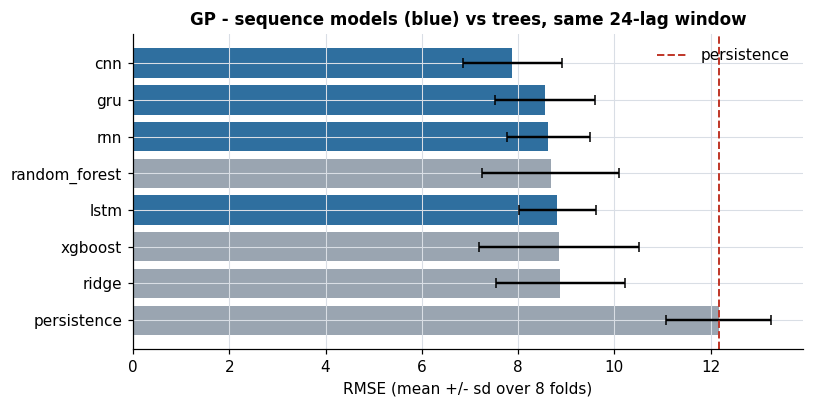

In [6]:

order = summary[summary["model"].isin(family)].sort_values("rmse_mean")
is_seq = order["model"].isin(["cnn", "lstm", "gru", "rnn"])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(order["model"], order["rmse_mean"],
        xerr=order["rmse_std"], capsize=3,
        color=["#2f6f9f" if s else "#9aa5b1" for s in is_seq])
ax.axvline(summary.loc[summary["model"] == "persistence", "rmse_mean"].iloc[0],
           color="#c0392b", ls="--", lw=1.3, label="persistence")
ax.invert_yaxis()
ax.set_xlabel("RMSE (mean +/- sd over 8 folds)")
ax.set_title(f"{OPERATOR.upper()} - sequence models (blue) vs trees, same 24-lag window")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / f"fig10_sequence_{OPERATOR}.png", dpi=200, bbox_inches="tight")


## What to take away

1. **The original's model ranking was an artefact of an unequal split**, not a finding
   about architectures.
2. **On GP the CNN does win**, by 9% over the best tree, and the margin survives a
   Diebold–Mariano test under FDR correction. On Robi nothing separates.
3. **The bigger lever is the lag window, not the model class.** Four lags to
   twenty-four buys 18% on GP for any model; the architecture buys 9% on top of that,
   on one operator only.
4. A confounded comparison can still reach a true answer. Separating the conclusion
   from the evidence is the whole point of the corrected protocol.

`experiments/run_sequence.py` runs both operators and writes
`sequence_{gp,robi}_{perfold,summary,dm}.csv` and `sequence_lag_depth.csv`.